# MCMC inference of the ENMV multi-host fitness landscape (n = 3)

This notebook performs Bayesian inference for the mechanistic model described in the associated manuscript. 
The objective is to estimate the geometry of host-specific phenotypic optima and host permissivity parameters 
from cross‑inoculation establishment data for endive necrotic mosaic virus (ENMV).

   - > Data required next to the notebook: `Data_RESISTE_ENMV.xlsx`

## 0) Configuration

Set:
- `N_DIM` : phenotype dimension $n$
- `KAPPA_FIX` : fixed Beta–Binomial concentration $\kappa$ (e.g. 10)
- MCMC settings (steps, burn-in, chains)

In [1]:
# --- Imports ---
import os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle
import multiprocessing as mp
from scipy.special import erfcx


# --- Core config ---
# dimension of phenotypic space
N_DIM = 3
# Fixed overdispersion parameter (from the statistical notebook)
KAPPA_FIX = 10.0

# Priors (uniform bounds)
PRIOR = dict(
    log10_U = (-4.0, 4.0),     # Lambda = log10(U)
    R = (0.01, 12.0),          
    q = (0.0, 10.0),           
    O = (-4.0, 4.0),           
)

# MCMC settings 
N_CHAINS = 10
N_STEPS  = 100000
BURN     = 50000
THIN     = 10

# Proposal step sizes (tune if acceptance too low/high)
sx = 2
STEP_LOG10_U = 0.04 / sx
STEP_LOGR      = 0.03 / sx
STEP_Q         = 0.08 / sx
STEP_O         = 0.05 / sx

# Progress printing
PRINT_EVERY = 5000

# Random seeds (one per chain)
BASE_SEED = 1000

# Output naming
OUT_PICKLE = f"posterior_n{N_DIM}.pkl"

print("posterior will be saved as =", OUT_PICKLE)

# Reproducibility helpers
def rng(seed):
    return np.random.default_rng(int(seed))

# Hosts
HOSTS = ["CH", "LA", "SA", "SO", "ZI"]
H = len(HOSTS)
host_to_idx = {h:i for i,h in enumerate(HOSTS)}

host_map = {
    "chicorée": "CH",
    "laitue": "LA",
    "salsifis": "SA",
    "souci": "SO",
    "zinnia": "ZI",
}

posterior will be saved as = posterior_n3.pkl


## 1) Load lineage‑level data and build count arrays

In [2]:
import warnings
warnings.filterwarnings("ignore", message="Workbook contains no default style")

DATA_RESISTE = "Data_RESISTE_ENMV.xlsx"
assert os.path.exists(DATA_RESISTE), f"Missing {DATA_RESISTE}. Put it next to this notebook."

raw = pd.read_excel(DATA_RESISTE, sheet_name="ENMV")

needed = ["sp_inoc", "soucheV", "plante_source", "infected"]
missing = [c for c in needed if c not in raw.columns]
assert not missing, f"Missing columns: {missing}. Columns found: {list(raw.columns)}"

raw["target"]  = raw["sp_inoc"].map(host_map)
raw["source"]  = raw["soucheV"].astype(str)
raw["lineage"] = raw["plante_source"].astype(str)
raw["y"]       = raw["infected"].astype(int)

valid_sources = ["7098MP1"] + HOSTS
raw = raw[raw["source"].isin(valid_sources)].copy()
raw = raw[raw["target"].isin(HOSTS)].copy()

# Split clonal vs evolved
df_clonal = raw[raw["source"]=="7098MP1"].copy()
df_evol   = raw[raw["source"]!="7098MP1"].copy()

# Clonal aggregated counts per target
clonal_counts = df_clonal.groupby("target")["y"].agg(["sum","count"]).reindex(HOSTS)
clonal_counts["rate"] = clonal_counts["sum"] / clonal_counts["count"]
display(clonal_counts)

# Evolved lineage-level counts per (source, lineage, target): each has n=12
lin = df_evol.groupby(["source","lineage","target"])["y"].agg(["sum","count"]).reset_index()
lin.rename(columns={"sum":"succ","count":"n"}, inplace=True)
assert lin["n"].min()==12 and lin["n"].max()==12, "Expected 12 plants per (source,lineage,target)."

# Enforce 8 lineages per source (and define a consistent lineage order)
lineages_by_source = {s: sorted(lin[lin["source"]==s]["lineage"].unique()) for s in HOSTS}
print("# lineages per source:", {s: len(v) for s,v in lineages_by_source.items()})
for s in HOSTS:
    assert len(lineages_by_source[s])==8, f"Expected 8 lineages for source {s}, got {len(lineages_by_source[s])}"

# Build array Y[src, tgt, s] = successes (0..12) for evolved
Y = np.zeros((H, H, 8), dtype=int)
for src in HOSTS:
    for si, lin_id in enumerate(lineages_by_source[src]):
        sub = lin[(lin["source"]==src) & (lin["lineage"]==lin_id)]
        # should contain one row per target
        for tgt in HOSTS:
            y = int(sub[sub["target"]==tgt]["succ"].iloc[0])
            Y[host_to_idx[src], host_to_idx[tgt], si] = y

# Convenience: clonal vectors
Y_CL = clonal_counts["sum"].astype(int).values
N_CL = clonal_counts["count"].astype(int).values

print("Y shape:", Y.shape, " (sources x targets x lineages)")
print("Clonal N:", dict(zip(HOSTS, N_CL)))


,sum,count,rate
target,,,
CH,19,20,0.950
LA,16,20,0.800
SA,21,40,0.525
SO,0,60,0.000
ZI,4,20,0.200


# lineages per source: {'CH': 8, 'LA': 8, 'SA': 8, 'SO': 8, 'ZI': 8}
Y shape: (5, 5, 8)  (sources x targets x lineages)
Clonal N: {'CH': 20, 'LA': 20, 'SA': 40, 'SO': 60, 'ZI': 20}


### Observed aggregated rates (for PPC plots)

In [3]:
# Evolved aggregated rates (96 plants per cell)
agg_evol = Y.sum(axis=2)  # H x H
rate_evol = agg_evol / 96.0

# Clonal rate vector
rate_cl = Y_CL / N_CL

# Flatten observed for a combined PPC scatter
obs_labels = []
obs_rates  = []

# clonal
for k, tgt in enumerate(HOSTS):
    obs_labels.append(f"CL->{tgt}")
    obs_rates.append(rate_cl[k])

# evolved
for j, src in enumerate(HOSTS):
    for k, tgt in enumerate(HOSTS):
        obs_labels.append(f"{src}->{tgt}")
        obs_rates.append(rate_evol[j,k])

obs_rates = np.asarray(obs_rates, float)

print("Observed rates summary:")
print("  min:", obs_rates.min(), "max:", obs_rates.max(), "mean:", obs_rates.mean())


Observed rates summary:
  min: 0.0 max: 1.0 mean: 0.5974305555555556


## 2) Mechanistic mapping $d_{jk}\mapsto p_{jk}$

For a pair $(j,k)$ with distance $d_{jk}$, the mechanistic evolutionary-rescue probability is

$$
\left\{
\begin{aligned}
p_{jk}
&= 1-\exp\!\left(
-q_k\left(
\nu_{jk} + r_{jk}^*+\sqrt{2\nu_{jk}+(r_{jk}^*)^2}
\right)
\right),\\
\nu_{jk}
&= 2U\,\Pi(j,k),\\
 r_{jk}^* & = 1-\frac{d_{jk}^2}{R_k^2},
\end{aligned}
\right.
$$
with
$$
\Pi(j,k)\approx \min\!\left(G(j,k),L(j,k)\right).
$$
$$
\left\{
\begin{aligned}
G(j,k)
& =
\mu\,\Phi\!\left(\frac{\mu}{\sigma}\right)
+
\sigma\,\varphi\!\left(\frac{\mu}{\sigma}\right),\\
L(j,k) &=
\frac{1}{R_k}\left(
\frac{\sqrt{2}}{\sqrt{\pi}}
-
y_{jk}
e^{y_{jk}^2/2}
\mathrm{Erfc}\!\left(\frac{y_{jk}}{\sqrt{2}}\right)
\right)
\left(\frac{R_k}{d_{jk}}\right)^{\frac{n-1}{2}}
e^{-(d_{jk}-R_k)^2/2},
\end{aligned}
\right.
$$
where $\Phi$ and $\varphi$ denote the cumulative distribution function and the
density of the standard normal distribution, respectively, and
$$
\mu = 1-\frac{d_{jk}^2+n}{R_k^2},
\qquad
\sigma = \frac{\sqrt{2n+4d_{jk}^2}}{R_k^2},
\qquad
y_{jk}=d_{jk}+\frac{n}{2R_k}-R_k.
$$

In [4]:
# Numerical safety
EPS_P = 1e-6          # to keep p in (0,1)

def G_from_d2(d2, R, n_dim):
    R2 = R * R

    mu = 1.0 - (d2 + n_dim) / R2
    sig2 = (4.0 * d2 + 2.0 * n_dim) / (R2 * R2)
    sig = math.sqrt(max(sig2, 1e-15))

    z = mu / sig

    Phi_z = stats.norm.cdf(z)
    phi_z = stats.norm.pdf(z)

    G = mu * Phi_z + sig * phi_z
    return max(G, 0.0)
    

def L_from_d2(d2, R, n_dim):
    d = math.sqrt(max(d2, 0.0))

    # L is not meant to be used near d=0 anyway
    if d < 1e-8:
        return float("inf")

    y = d + n_dim / (2.0 * R) - R
    z = y / math.sqrt(2.0)

    pref = (1.0 / R) * ((R / d) ** ((n_dim - 1.0) / 2.0))
    expo = math.exp(-0.5 * (d - R) * (d - R))

    # Stable version of:
    # sqrt(2/pi) - y * exp(y^2/2) * erfc(y/sqrt(2))
    bracket = math.sqrt(2.0 / math.pi) - y * erfcx(z)

    L = pref * expo * bracket

    if not math.isfinite(L):
        return float("inf")

    return max(L, 0.0)


def Pi_from_d2(d2, R, n_dim):
    G = G_from_d2(d2=d2, R=R, n_dim=n_dim)
    L = L_from_d2(d2=d2, R=R, n_dim=n_dim)
    return min(G, L)


def p_from_d2(d2, log10_U, R, qk, n_dim, eps_p=EPS_P):
    U = 10.0 ** log10_U
    R2 = R * R

    r = 1.0 - d2 / R2
    Pi_hat = Pi_from_d2(d2=d2, R=R, n_dim=n_dim)
    nu = 2.0 * U * Pi_hat

    inside = r + nu  + math.sqrt(2.0 * nu + r * r) 
    rate = qk * max(inside, 0.0)

    p = 1.0 - math.exp(-rate)
    return min(max(p, eps_p), 1.0 - eps_p)



def build_p_matrix(O, log10_U, Rk, n_dim, qk):
    # O: (H,n_dim) optima for CH,LA,SA,SO,ZI (in HOSTS order)
    # Rk: one geometric scale R_k per target host (HOSTS order)
    # qk: one target-specific q_k per target host (HOSTS order)
    # Returns:
    #  p_cl[k] for CL->k
    #  p_evol[j,k] for source j -> target k
    if np.isscalar(Rk):
        Rk = np.full(H, float(Rk))
    else:
        Rk = np.asarray(Rk, float).reshape(-1)
        assert Rk.size == H, f"Expected Rk of length {H}, got {Rk.size}"

    qk = np.asarray(qk, float).reshape(-1)
    assert qk.size == H, f"Expected qk of length {H}, got {qk.size}"

    p_cl = np.zeros(H, float)
    p_evol = np.zeros((H, H), float)

    # CL is at origin, so d2 = ||O_k||^2
    for k in range(H):
        d2 = float(np.dot(O[k], O[k]))
        p = p_from_d2(d2, log10_U, float(Rk[k]), float(qk[k]), n_dim)
        p_cl[k] = min(max(p, EPS_P), 1.0 - EPS_P)

    # evolved: distances between optima
    for j in range(H):
        for k in range(H):
            d = O[j] - O[k]
            d2 = float(np.dot(d, d))
            p = p_from_d2(d2, log10_U, float(Rk[k]), float(qk[k]), n_dim)
            p_evol[j, k] = min(max(p, EPS_P), 1.0 - EPS_P)

    return p_cl, p_evol


## 3) Likelihood: Binomial for clonal + Beta-Binomial for lineage-level evolved

In [5]:
def loglik(theta, n_dim, kappa=KAPPA_FIX):
    # theta = (log10_U, logR_k (k=1..H), q_k (k=1..H), O_flat)
    log10_U = float(theta[0])
    logRk = np.asarray(theta[1:1+H], float)
    Rk = np.exp(logRk)
    qk = np.asarray(theta[1+H:1+2*H], float)
    O_flat = theta[1+2*H:]
    O = O_flat.reshape(H, n_dim)

    # Prior bounds (uniform)
    lo, hi = PRIOR["log10_U"]
    if not (lo <= log10_U <= hi):
        return -np.inf
    Rlo, Rhi = PRIOR["R"]
    if np.any(Rk < Rlo) or np.any(Rk > Rhi):
        return -np.inf
    qlo, qhi = PRIOR["q"]
    if np.any(qk < qlo) or np.any(qk > qhi):
        return -np.inf
    Olo, Ohi = PRIOR["O"]
    if np.any(O < Olo) or np.any(O > Ohi):
        return -np.inf

    p_cl, p_evol = build_p_matrix(O, log10_U, Rk, n_dim, qk=qk)

    ll = 0.0
    # clonal Binomial
    for k in range(H):
        ll += stats.binom.logpmf(Y_CL[k], N_CL[k], p_cl[k])

    # evolved lineage-level Beta-Binomial
    for j in range(H):
        for k in range(H):
            p = float(np.clip(p_evol[j,k], EPS_P, 1-EPS_P))
            a = kappa * p
            b = kappa * (1.0 - p)
            y_vec = Y[j,k,:]
            ll += float(np.sum(stats.betabinom.logpmf(y_vec, 12, a, b)))

    return float(ll)


def random_theta(seed, n_dim):
    r = rng(seed)
    log10_U = r.uniform(*PRIOR["log10_U"])
    Rk = r.uniform(PRIOR["R"][0], PRIOR["R"][1], size=H)
    logRk = np.log(Rk)
    qk = r.uniform(PRIOR["q"][0], PRIOR["q"][1], size=H)
    O = r.uniform(PRIOR["O"][0], PRIOR["O"][1], size=(H, n_dim))
    return np.concatenate([[log10_U], logRk, qk, O.reshape(-1)])

# Smoke test
theta_test = random_theta(0, N_DIM)
print("loglik(theta_test) =", loglik(theta_test, N_DIM, KAPPA_FIX))


loglik(theta_test) = -4562.936672072948


## 4) Initial point

In [6]:
def find_best_of_random_starts(n_starts, n_dim, seed=0, kappa=KAPPA_FIX):
    r = rng(seed)
    best = None
    best_ll = -np.inf
    for i in range(n_starts):
        th = random_theta(int(r.integers(0, 10**9)), n_dim)
        ll = loglik(th, n_dim, kappa)
        if ll > best_ll:
            best_ll = ll
            best = th
    return best, best_ll

# Quick warm-start search
N_STARTS = 200
t0 = time.time()
theta_map, ll_map = find_best_of_random_starts(N_STARTS, N_DIM, seed=123, kappa=KAPPA_FIX)
print(f"Best of {N_STARTS} random starts: loglik={ll_map:.2f}   (elapsed {time.time()-t0:.1f}s)")


Best of 200 random starts: loglik=-1087.17   (elapsed 2.0s)


## 5) Random-walk Metropolis MCMC

In [7]:
def run_chain(chain_id, theta0, n_dim, n_steps, burn, thin, step_scales, kappa, seed, print_every=200):
    r = rng(seed)
    d = theta0.size
    theta = theta0.copy()
    ll = loglik(theta, n_dim, kappa)

    # track best
    best_ll = ll
    best_theta = theta.copy()

    samples = []
    lls = []
    acc = 0

    t_start = time.time()
    last_t = t_start

    for t in range(1, n_steps+1):
        prop = theta + r.normal(scale=step_scales, size=d)
        ll_prop = loglik(prop, n_dim, kappa)

        if np.isfinite(ll_prop):
            if math.log(r.uniform()) < (ll_prop - ll):
                theta = prop
                ll = ll_prop
                acc += 1

        # update best
        if ll > best_ll:
            best_ll = ll
            best_theta = theta.copy()

        # store after burn with thinning
        if t > burn and ((t-burn) % thin == 0):
            samples.append(theta.copy())
            lls.append(ll)

        if (t % print_every) == 0:
            now = time.time()
            dt = now - last_t
            elapsed = now - t_start
            rate = elapsed / t
            gg = rate * (n_steps - t)
            acc_rate = acc / t
            print(f"[chain {chain_id}] {t:>6}/{n_steps}  acc={acc_rate:0.3f}  ll={ll:0.2f}  best_ll={best_ll:0.2f}  elapsed={elapsed/60:0.1f}min  ETA~{gg/60:0.1f}min  (+{dt:0.1f}s)")
            last_t = now

 #   print(f"[chain {chain_id}] BEST ll = {best_ll:.4f}")
 #   print(f"[chain {chain_id}] BEST theta = {best_theta}")

    out = dict(
        chain_id=chain_id,
        seed=seed,
        accept_rate=acc/n_steps,
        samples=np.asarray(samples),
        loglik=np.asarray(lls),
        last_theta=theta,
        last_loglik=ll,
        best_theta=best_theta,
        best_loglik=best_ll,
    )
    return out
def run_mcmc_parallel(theta_start, n_dim, n_chains, n_steps, burn, thin, kappa=KAPPA_FIX, n_proc=30):
    d = theta_start.size
    step = np.zeros(d, float)
    step[0] = STEP_LOG10_U
    step[1:1+H] = STEP_LOGR
    step[1+H:1+2*H] = STEP_Q
    step[1+2*H:] = STEP_O

    # Different initial points per chain: jitter around MAP
    inits = []
    seeds = []
    for c in range(n_chains):
        sd = BASE_SEED + c
        seeds.append(sd)
        r = rng(sd)
        th0 = theta_start.copy()
        th0 += r.normal(scale=step*2.0, size=d)  # small jitter
        inits.append(th0)

    args = []
    for c in range(n_chains):
        args.append((c, inits[c], n_dim, n_steps, burn, thin, step, kappa, seeds[c], PRINT_EVERY))

    # Limit processes
    n_proc = int(min(n_proc, n_chains, mp.cpu_count()))
    if n_proc <= 1:
        results = [run_chain(*a) for a in args]
    else:
        ctx = mp.get_context("fork")  # usually best in local notebooks
        with ctx.Pool(processes=n_proc) as pool:
            results = pool.starmap(run_chain, args)

    return results

# Run MCMC (parallel over chains)
results = run_mcmc_parallel(theta_map, N_DIM, N_CHAINS, N_STEPS, BURN, THIN, kappa=KAPPA_FIX, n_proc=30)

for r in results:
    print(f"Chain {r['chain_id']} accept_rate={r['accept_rate']:.3f}  n_saved={len(r['samples'])}")


best_chain = max(results, key=lambda r: r["best_loglik"])

print("\n===== GLOBAL BEST =====")
print("chain:", best_chain["chain_id"])
print("loglik:", best_chain["best_loglik"])
print("theta:", best_chain["best_theta"])

[chain 7]   5000/100000  acc=0.299  ll=-376.25  best_ll=-375.77  elapsed=0.8min  ETA~15.9min  (+50.3s)
[chain 2]   5000/100000  acc=0.316  ll=-378.86  best_ll=-374.08  elapsed=0.9min  ETA~16.4min  (+51.8s)
[chain 6]   5000/100000  acc=0.332  ll=-380.96  best_ll=-376.29  elapsed=0.9min  ETA~16.5min  (+52.0s)
[chain 0]   5000/100000  acc=0.280  ll=-383.46  best_ll=-375.80  elapsed=0.9min  ETA~16.6min  (+52.3s)
[chain 4]   5000/100000  acc=0.362  ll=-327.58  best_ll=-323.77  elapsed=0.9min  ETA~16.6min  (+52.4s)
[chain 1]   5000/100000  acc=0.335  ll=-380.39  best_ll=-375.62  elapsed=0.9min  ETA~16.6min  (+52.6s)
[chain 8]   5000/100000  acc=0.337  ll=-380.22  best_ll=-374.94  elapsed=0.9min  ETA~16.8min  (+53.1s)
[chain 9]   5000/100000  acc=0.283  ll=-378.51  best_ll=-378.51  elapsed=0.9min  ETA~17.0min  (+53.6s)
[chain 5]   5000/100000  acc=0.343  ll=-377.03  best_ll=-376.10  elapsed=0.9min  ETA~17.0min  (+53.7s)
[chain 3]   5000/100000  acc=0.334  ll=-384.57  best_ll=-375.90  elapsed=

## 6) Save posterior to pickle

In [8]:
posterior = {
    "model": "distance_only_closed_form_with_qk + BetaBinomial(lineage-level)",
    "n_dim": N_DIM,
    "kappa": float(KAPPA_FIX),
    "priors": PRIOR,
    "eps_p": EPS_P,
    "data": {
        "hosts": HOSTS,
        "Y": Y,
        "Y_CL": Y_CL,
        "N_CL": N_CL,
        "lineages_by_source": lineages_by_source,
    },
    "mcmc": {
        "n_chains": N_CHAINS,
        "n_steps": N_STEPS,
        "burn": BURN,
        "thin": THIN,
        "step_log10_U": STEP_LOG10_U,
        "step_logR": STEP_LOGR,
        "step_q": STEP_Q,
        "step_O": STEP_O,
    },
    "chains": results,
}

with open(OUT_PICKLE, "wb") as f:
    pickle.dump(posterior, f)

print("Saved:", OUT_PICKLE)


Saved: posterior_n3.pkl


## 7) Posterior summaries (distance matrix, MDS, PPC, posterior distributions)

In [9]:
def unpack_samples(chains):
    # returns concatenated samples array (n_total, d)
    all_s = [c["samples"] for c in chains]
    return np.vstack(all_s)

def theta_to_params(theta, n_dim):
    theta = np.asarray(theta, float)
    # parameterization:
    # theta = (log10_U, logR_k (k=1..H), q_k (k=1..H), O_flat)
    log10_U = float(theta[0])
    logRk = theta[1:1+H]
    Rk = np.exp(logRk)
    qk = theta[1+H:1+2*H]
    O = theta[1+2*H:].reshape(H, n_dim)
    return log10_U, Rk, qk, O

def dist_matrix_with_CL(O):
    # returns (H+1,H+1) with CL index 0 then hosts 1..H
    pts = np.vstack([np.zeros((1,O.shape[1])), O])  # (H+1, n_dim)
    m = pts.shape[0]
    D = np.zeros((m,m), float)
    for i in range(m):
        for j in range(m):
            d = pts[i]-pts[j]
            D[i,j] = float(np.sqrt(np.dot(d,d)))
    return D

def classical_mds(D, out_dim=2):
    # Classical MDS from distances
    D = np.asarray(D, float)
    n = D.shape[0]
    J = np.eye(n) - np.ones((n,n))/n
    B = -0.5 * J @ (D**2) @ J
    # eigendecomposition
    w, V = np.linalg.eigh(B)
    idx = np.argsort(w)[::-1]
    w = w[idx]
    V = V[:, idx]
    w = np.maximum(w, 0)
    L = np.diag(np.sqrt(w[:out_dim]))
    X = V[:, :out_dim] @ L
    return X

def procrustes_align(X, Xref):
    # Align X to Xref by optimal rotation + translation (no scaling)
    Xc = X - X.mean(axis=0, keepdims=True)
    Yc = Xref - Xref.mean(axis=0, keepdims=True)
    U, s, Vt = np.linalg.svd(Xc.T @ Yc, full_matrices=False)
    Rm = U @ Vt
    X_al = Xc @ Rm
    # translate to ref mean
    X_al += Xref.mean(axis=0, keepdims=True)
    return X_al

def ellipse_points(mean, cov, level=0.95, n_points=120):
    # 2D ellipse for covariance
    q = stats.chi2.ppf(level, df=2)
    w, V = np.linalg.eigh(cov)
    w = np.maximum(w, 1e-12)
    t = np.linspace(0, 2*np.pi, n_points)
    circle = np.vstack([np.cos(t), np.sin(t)])  # 2 x N
    ell = (V @ (np.diag(np.sqrt(w*q)) @ circle)).T
    return ell + mean

samples = unpack_samples(results)
print("Total saved samples:", samples.shape)

# Posterior mean distance matrix
Ds = np.array([dist_matrix_with_CL(theta_to_params(th, N_DIM)[3]) for th in samples])
D_mean = Ds.mean(axis=0)

labels = ["CL"] + HOSTS


Total saved samples: (50000, 26)


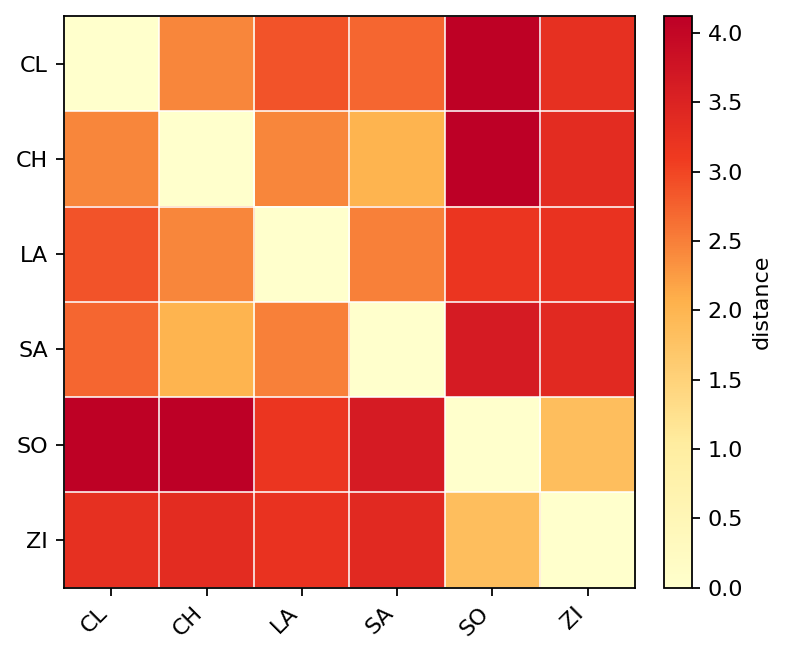

In [10]:
# Distance matrix
from matplotlib.colors import LinearSegmentedColormap


cmap_white_black = LinearSegmentedColormap.from_list(
    "white_black",
    ["#ffffff", "#000000"],
    N=256,
)

cmap_yellow_red = LinearSegmentedColormap.from_list(
    "yellow_red",
    ["#ffffcc", "#ffeda0", "#feb24c", "#f03b20", "#bd0026"],
    N=256,
)


fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=160)

vmin = 0
vmax = np.nanpercentile(D_mean, 99)

im = ax.imshow(
    D_mean,
    origin="upper",
    cmap=cmap_yellow_red,
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest",
)

ax.set_xticks(range(H+1))
ax.set_yticks(range(H+1))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# optional: grid for readability
ax.set_xticks(np.arange(-.5, H+1, 1), minor=True)
ax.set_yticks(np.arange(-.5, H+1, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.7)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("distance")

ax.set_aspect("equal")
fig.tight_layout()
fig.savefig("posterior_distance_n3.png", dpi=300, bbox_inches="tight")
plt.show()


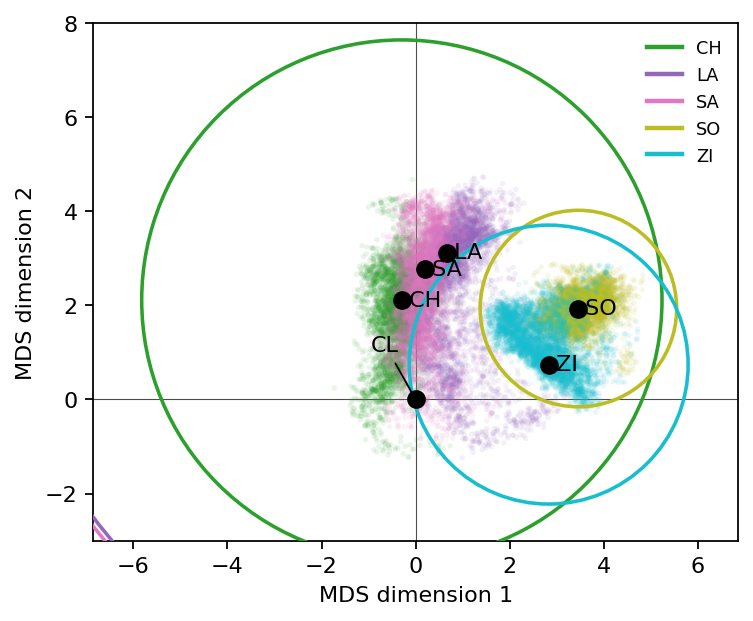

In [11]:
# Panel B: MDS + posterior clouds and R_k circles (with posterior modes)

from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# -----------------------------
# Settings
# -----------------------------
n_preview = 5000
seed_preview = 0
epsilon = 1e-6  # only for reference; not used directly here

# KDE mode settings
KDE_GRIDSIZE = 180   # higher = more accurate but slower
KDE_PAD = 0.20       # expand grid bounds by this fraction
KDE_BW = None        # can set e.g. "scott" or "silverman" or a float

def kde_mode_2d(pts, gridsize=180, pad=0.2, bw_method=None):
    """
    Approximate the 2D KDE mode by evaluating KDE on a regular grid.
    pts: (N,2) array
    returns: (2,) point of maximum estimated density
    """
    pts = np.asarray(pts)
    if pts.shape[0] < 5:
        return pts.mean(axis=0)

    kde = gaussian_kde(pts.T, bw_method=bw_method)

    xmin, ymin = pts.min(axis=0)
    xmax, ymax = pts.max(axis=0)

    dx = xmax - xmin
    dy = ymax - ymin
    # handle degenerate spreads
    if dx == 0:
        dx = 1.0
    if dy == 0:
        dy = 1.0

    xmin -= pad * dx
    xmax += pad * dx
    ymin -= pad * dy
    ymax += pad * dy

    xs = np.linspace(xmin, xmax, gridsize)
    ys = np.linspace(ymin, ymax, gridsize)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.vstack([Xg.ravel(), Yg.ravel()])

    dens = kde(grid).reshape(gridsize, gridsize)
    iy, ix = np.unravel_index(np.argmax(dens), dens.shape)
    return np.array([xs[ix], ys[iy]], dtype=float)


# -----------------------------
# Subsample posterior draws for clouds
# -----------------------------
n_all = len(Ds)
if n_all > n_preview:
    rng = np.random.default_rng(seed_preview)
    idx = rng.choice(n_all, size=n_preview, replace=False)
else:
    idx = np.arange(n_all)

# -----------------------------
# Compute MDS coordinates for reference and posterior draws
# -----------------------------
Xref = classical_mds(D_mean, out_dim=2)

Xs = []
for j in idx:
    X = classical_mds(Ds[j], out_dim=2)
    X = procrustes_align(X, Xref)
    Xs.append(X)
Xs = np.array(Xs)  # shape: (n_used, H+1, 2)

# -----------------------------
# Extract posterior radii and compute mean radius (circles)
# -----------------------------
Rks = np.array([theta_to_params(th, N_DIM)[1] for th in samples])  # shape: (n_samp, H)
Rk_mean = Rks.mean(axis=0)

# -----------------------------
# Colors
# -----------------------------
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

# -----------------------------
# Posterior modes in 2D (KDE argmax)
# -----------------------------
modes = np.zeros((len(labels), 2), dtype=float)
for i, lab in enumerate(labels):
    pts_i = Xs[:, i, :]          # (n_used, 2)
    modes[i] = kde_mode_2d(pts_i, gridsize=KDE_GRIDSIZE, pad=KDE_PAD, bw_method=KDE_BW)

# -----------------------------
# Translate so that CL mode is at (0,0)
# -----------------------------
cl_idx = labels.index("CL")      # assumes "CL" exists
origin = modes[cl_idx].copy()

Xs = Xs - origin[None, None, :]
modes = modes - origin[None, :]

# -----------------------------
# Plot styling
# -----------------------------
alpha_cloud = 0.10
z_circle = 3
z_cloud  = 2
z_mode   = 5

fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=160)

for i, lab in enumerate(labels):
    pts = Xs[:, i, :]
    col = colors[i]
    mode_pt = modes[i]

    # Draw the R_k circle (skip CL)
    if lab != "CL":
        k = i - 1  # assumes labels = ["CL", host1, host2, ...] OR CL at index 0
        # If CL is not at index 0, adjust mapping. This is your original assumption.
        ax.add_patch(
            Circle(
                (float(mode_pt[0]), float(mode_pt[1])),
                float(Rk_mean[k]),
                fill=False,
                lw=1.6,
                edgecolor=col,
                zorder=z_circle,
            )
        )

    # Posterior cloud (skip CL like your original code)
    if lab != "CL":
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=6,
            alpha=alpha_cloud,
            color=col,
            edgecolors="none",
            zorder=z_cloud,
        )

    # Mode marker (KDE mode)
    ax.scatter(mode_pt[0], mode_pt[1], s=55, color="k", zorder=z_mode)

    # Labels
    if lab == "CL":
        x0, y0 = float(mode_pt[0]), float(mode_pt[1])
        ax.annotate(
            "CL",
            xy=(x0, y0),
            xytext=(-20, 20),
            textcoords="offset points",
            ha="left",
            va="bottom",
            color="k",
            arrowprops=dict(arrowstyle="-", color="k", lw=0.8),
            zorder=z_mode + 2,
        )
    else:
        ax.text(
            mode_pt[0],
            mode_pt[1],
            f" {lab}",
            va="center",
            color="k",
            zorder=z_mode + 1,
        )

# Reference axes through origin
ax.axhline(0, lw=0.5, color="0.3", zorder=0)
ax.axvline(0, lw=0.5, color="0.3", zorder=0)

ax.set_xlabel("MDS dimension 1")
ax.set_ylabel("MDS dimension 2")
ax.set_aspect("equal", adjustable="datalim")

# Legend (exclude CL)
handles = []
for i, lab in enumerate(labels):
    if lab == "CL":
        continue
    handles.append(Line2D([0], [0], color=colors[i], lw=2, label=lab))
ax.legend(handles=handles, frameon=False, loc="best", fontsize=8, title_fontsize=9)

ax.set_xlim(-5, 5)
ax.set_ylim(-3, 8)
fig.savefig("MDS_n3.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
print("Rks type:", type(Rks), "shape:", getattr(Rks, "shape", None), "dtype:", getattr(Rks, "dtype", None))
print("Rk_mean type:", type(Rk_mean), "shape:", getattr(Rk_mean, "shape", None))
print("Example theta_to_params(...)[1]:", theta_to_params(samples[0], N_DIM)[1], type(theta_to_params(samples[0], N_DIM)[1]))

Rks type: <class 'numpy.ndarray'> shape: (50000, 5) dtype: float64
Rk_mean type: <class 'numpy.ndarray'> shape: (5,)
Example theta_to_params(...)[1]: [4.66597205 7.50138991 5.97317529 1.23051735 2.446688  ] <class 'numpy.ndarray'>


PPC RMSE (rates): 0.04438560038033374


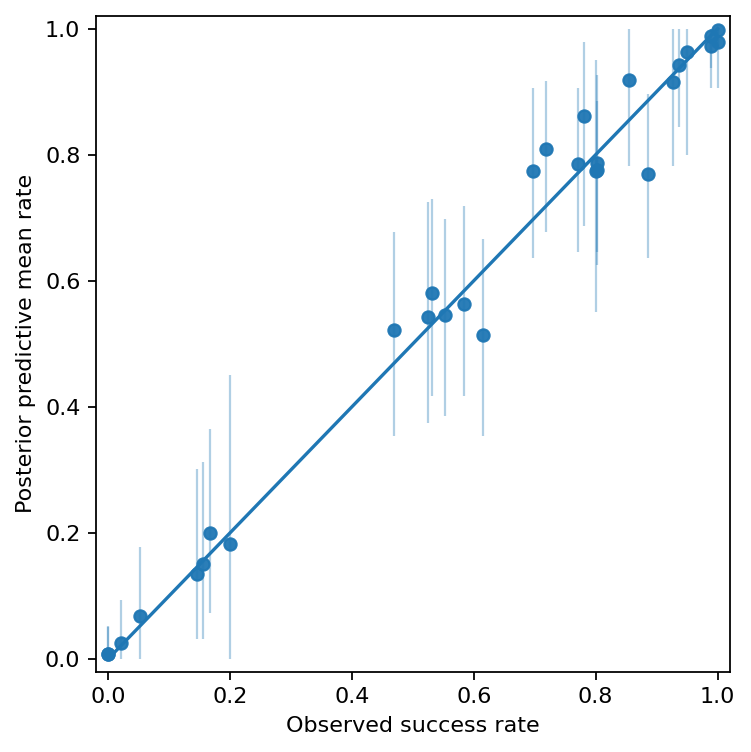

In [13]:
def ppc_rate_draws(samples, n_dim, kappa=KAPPA_FIX, n_ppc=800, seed=0):
    r = np.random.default_rng(seed)
    idx = r.integers(0, samples.shape[0], size=n_ppc)

    pred_draws = []
    for t in idx:
        log10_U, Rk, qk, O = theta_to_params(samples[t], n_dim)
        p_cl, p_evol = build_p_matrix(O, log10_U, Rk, n_dim, qk=qk)

        # clonal simulation
        cl_sim = np.array([r.binomial(N_CL[k], p_cl[k]) for k in range(H)])

        # evolved simulation
        ev_sim = np.zeros((H, H), int)
        for j in range(H):
            for k in range(H):
                p = float(np.clip(p_evol[j, k], EPS_P, 1 - EPS_P))
                a = kappa * p
                b = kappa * (1 - p)
                pis = r.beta(a, b, size=8)
                ys  = r.binomial(12, pis)
                ev_sim[j, k] = int(ys.sum())

        # aggregated rates in the same order as obs_rates
        rates = []
        for k in range(H):
            rates.append(cl_sim[k] / N_CL[k])
        for j in range(H):
            for k in range(H):
                rates.append(ev_sim[j, k] / 96.0)

        pred_draws.append(rates)

    return obs_rates, np.asarray(pred_draws, float)
obs, pred_draws = ppc_rate_draws(samples, N_DIM, kappa=KAPPA_FIX, n_ppc=1000, seed=0)

pred_mean = pred_draws.mean(axis=0)
pred_lo   = np.quantile(pred_draws, 0.025, axis=0)
pred_hi   = np.quantile(pred_draws, 0.975, axis=0)

rmse = float(np.sqrt(np.mean((pred_mean - obs)**2)))
print("PPC RMSE (rates):", rmse)
fig, ax = plt.subplots(figsize=(4.8, 4.8), dpi=160)

# vertical 95% predictive intervals
ax.vlines(obs, pred_lo, pred_hi, lw=1.0, alpha=0.35)

# mean prediction
ax.scatter(obs, pred_mean, s=30, alpha=0.95)

# identity line
ax.plot([0, 1], [0, 1], lw=1.5)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Observed success rate")
ax.set_ylabel("Posterior predictive mean rate")
#ax.set_title("Posterior predictive check (95% intervals)")

fig.tight_layout()
fig.savefig("PPC_n3.png", dpi=300, bbox_inches="tight")
plt.show()


Lambda (log10(U))
  MAP (posterior mode) : -0.7870
  median              : -0.6432
  mean ± sd           : -0.6899 ± 0.4314
  95% CrI             : [-1.5934, 0.0277]


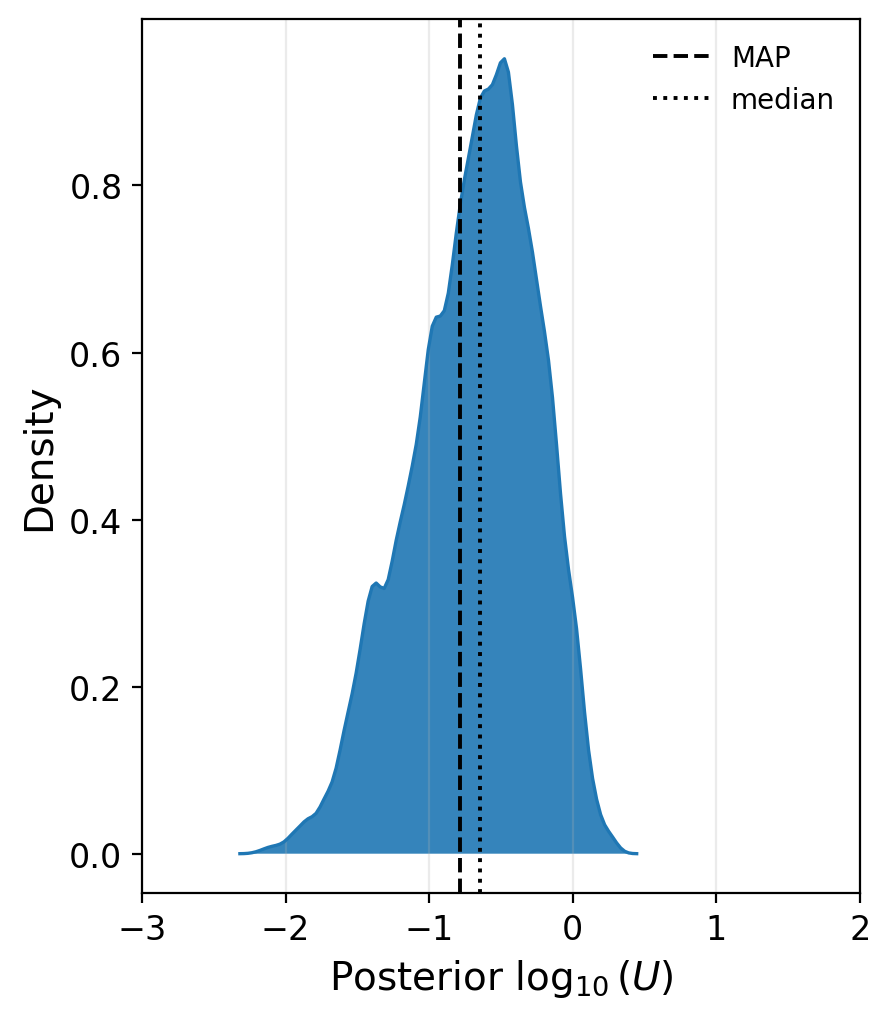

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# --- Posterior mode (MAP) and uncertainty for Lambda = log10(U) ---

# 1) Extract Lambda samples (same order as 'samples')
Lambda_samp = np.array([theta_to_params(th, N_DIM)[0] for th in samples])
Lambda_samp = Lambda_samp[np.isfinite(Lambda_samp)]

# 2) Extract matching log-likelihoods (same order as concatenated samples)
loglik_samp = np.concatenate([c["loglik"] for c in posterior["chains"]])

assert len(Lambda_samp) == len(loglik_samp), "Mismatch: samples vs loglik lengths."

# 3) Posterior mode as MAP draw (max log-likelihood; priors are uniform here)
i_map = int(np.argmax(loglik_samp))
Lambda_map = float(Lambda_samp[i_map])

# 4) Uncertainty summaries
q025, q50, q975 = np.quantile(Lambda_samp, [0.025, 0.50, 0.975])
Lambda_mean = float(np.mean(Lambda_samp))
Lambda_sd = float(np.std(Lambda_samp, ddof=1))

print("Lambda (log10(U))")
print(f"  MAP (posterior mode) : {Lambda_map:.4f}")
print(f"  median              : {q50:.4f}")
print(f"  mean ± sd           : {Lambda_mean:.4f} ± {Lambda_sd:.4f}")
print(f"  95% CrI             : [{q025:.4f}, {q975:.4f}]")

# 5) Smoothed histogram-based posterior density plot for Lambda
fig, ax = plt.subplots(figsize=(4.5, 5.2), dpi=200)

xmin, xmax = Lambda_samp.min(), Lambda_samp.max()
xpad = 0.05 * (xmax - xmin)

n_bins = 100
bins = np.linspace(xmin - xpad, xmax + xpad, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Histogram in density form
counts, _ = np.histogram(Lambda_samp, bins=bins, density=True)

# Very light Gaussian smoothing of the histogram counts
sigma = 1.5
counts_smooth = gaussian_filter1d(counts, sigma=sigma, mode="nearest")

# Filled density
ax.fill_between(bin_centers, 0, counts_smooth, alpha=0.9)
ax.plot(bin_centers, counts_smooth, linewidth=1.2)

# MAP and median
ax.axvline(Lambda_map, color="k", linewidth=1.4, linestyle="--", label="MAP")
ax.axvline(q50, color="k", linewidth=1.4, linestyle=":", label="median")

ax.set_xlabel(r"Posterior $\log_{10}(U)$", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, fontsize=10)

fig.tight_layout()
ax.set_xlim(-3, 2)
fig.savefig("posteriorLambda_n3.png", dpi=300, bbox_inches="tight")
plt.show()

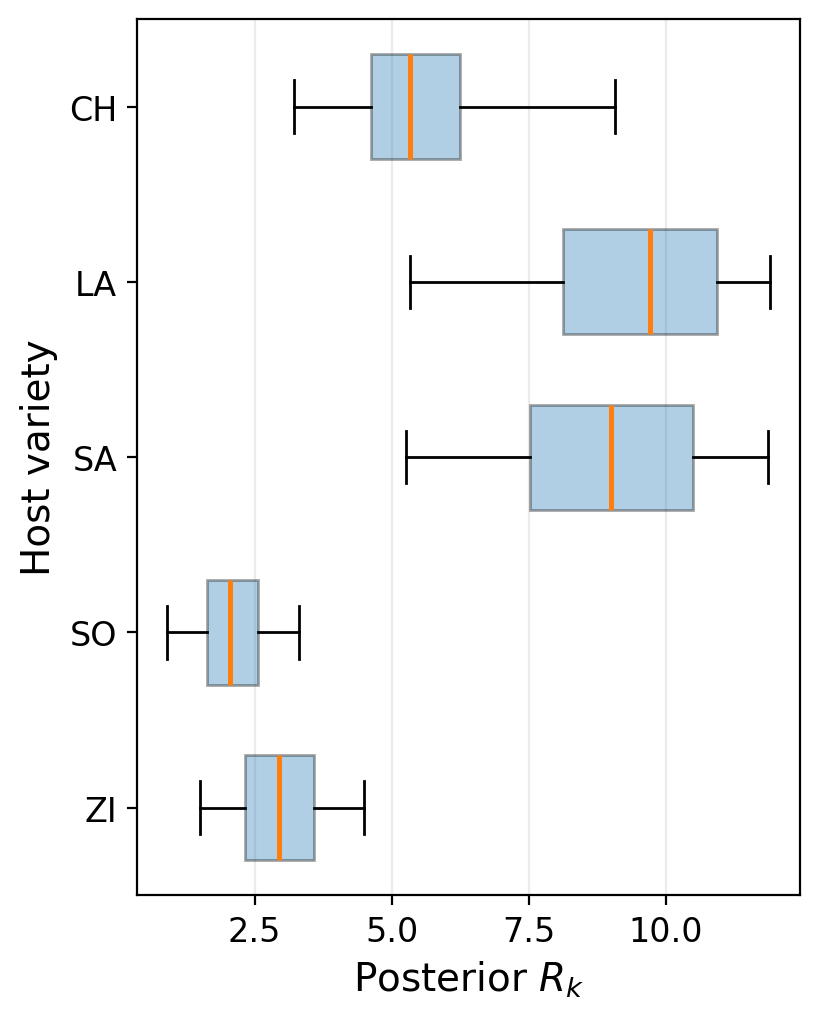

In [27]:

# --- 1) Extract posterior samples of R_k ---
Rks = np.array([theta_to_params(th, N_DIM)[1] for th in samples])
Rks = Rks[np.all(np.isfinite(Rks), axis=1), :]

# --- 2) Figure: vertical boxplots (labels on the y-axis) ---
fig, ax = plt.subplots(figsize=(4.2, 5.2), dpi=200)

bp = ax.boxplot(
    [Rks[:, k] for k in range(Rks.shape[1])],
    vert=False,
    labels=HOSTS,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
    whis=(2.5, 97.5),
    medianprops=dict(linewidth=1.8),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
)

for box in bp["boxes"]:
    box.set_alpha(0.35)

ax.set_xlabel(r"Posterior $R_k$", fontsize=14)
ax.set_ylabel("Host variety", fontsize=14)

# Slightly larger ticks
ax.tick_params(axis="both", labelsize=12)

ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig("posterior_Rk_n3.png", dpi=300, bbox_inches="tight")
plt.show()

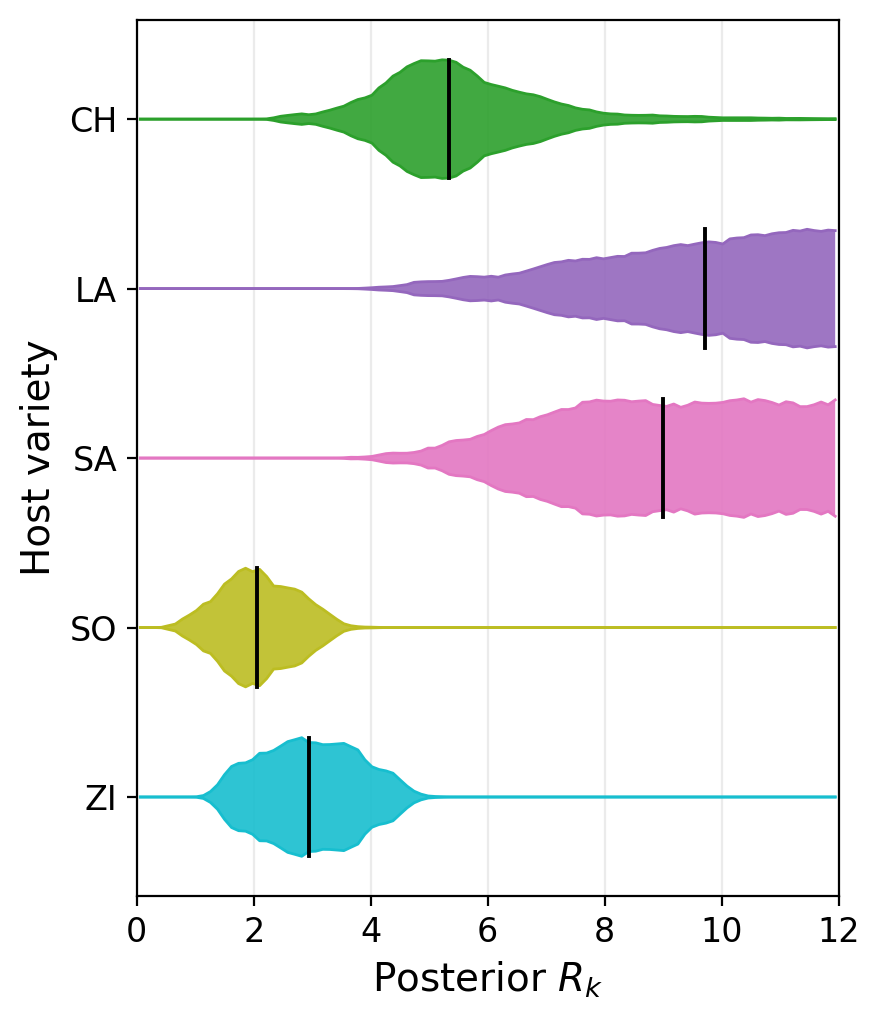

In [28]:
from scipy.ndimage import gaussian_filter1d

# --- 1) Extract posterior samples of R_k ---
Rks = np.array([theta_to_params(th, N_DIM)[1] for th in samples])
Rks = Rks[np.all(np.isfinite(Rks), axis=1), :]   # shape: (n_samples, n_hosts)

# --- 2) Same color palette ---
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))
host_to_color = {lab: colors[labels.index(lab)] for lab in HOSTS}

# --- 3) Figure ---
fig, ax = plt.subplots(figsize=(4.5, 5.2), dpi=200)
ypos = np.arange(1, len(HOSTS) + 1)

lower, upper = 0.0, 12.0
n_bins = 100                     # increase if you want a finer histogram
bins = np.linspace(lower, upper, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

scale = 0.35
sigma = 0.5                      # very light smoothing

for y0, host, samp in zip(ypos, HOSTS, Rks.T):
    col = host_to_color[host]

    samp = samp[(samp >= lower) & (samp <= upper)]

    # histogram in density form
    counts, _ = np.histogram(samp, bins=bins, density=True)

    # smooth the counts without leaking outside the support
    counts_smooth = gaussian_filter1d(counts, sigma=sigma, mode="nearest")

    # normalize for visualization
    h = counts_smooth / counts_smooth.max() * scale

    ax.fill_between(
        bin_centers,
        y0 - h,
        y0 + h,
        facecolor=col,
        edgecolor="none",
        alpha=0.9,
        zorder=2,
    )

    ax.plot(bin_centers, y0 + h, color=col, linewidth=1.0, zorder=3)
    ax.plot(bin_centers, y0 - h, color=col, linewidth=1.0, zorder=3)

    med = np.median(samp)
    ax.plot([med, med], [y0 - scale, y0 + scale], color="k", linewidth=1.4, zorder=4)

ax.set_yticks(ypos)
ax.set_yticklabels(HOSTS)
ax.set_xlabel(r"Posterior $R_k$", fontsize=14)
ax.set_ylabel("Host variety", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25, zorder=0)
ax.set_xlim(lower, upper)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig("posterior_Rk_n3.png", dpi=300, bbox_inches="tight")
plt.show()

Posterior summaries for q_k
CH: mean=1.7404  median=1.7485  95% CrI=[0.8385, 2.6963]
LA: mean=0.5886  median=0.5895  95% CrI=[0.3114, 0.8617]
SA: mean=0.3072  median=0.3083  95% CrI=[0.1592, 0.4507]
SO: mean=3.9690  median=3.6736  95% CrI=[1.3575, 8.2049]
ZI: mean=1.3520  median=0.9742  95% CrI=[0.5167, 8.4789]


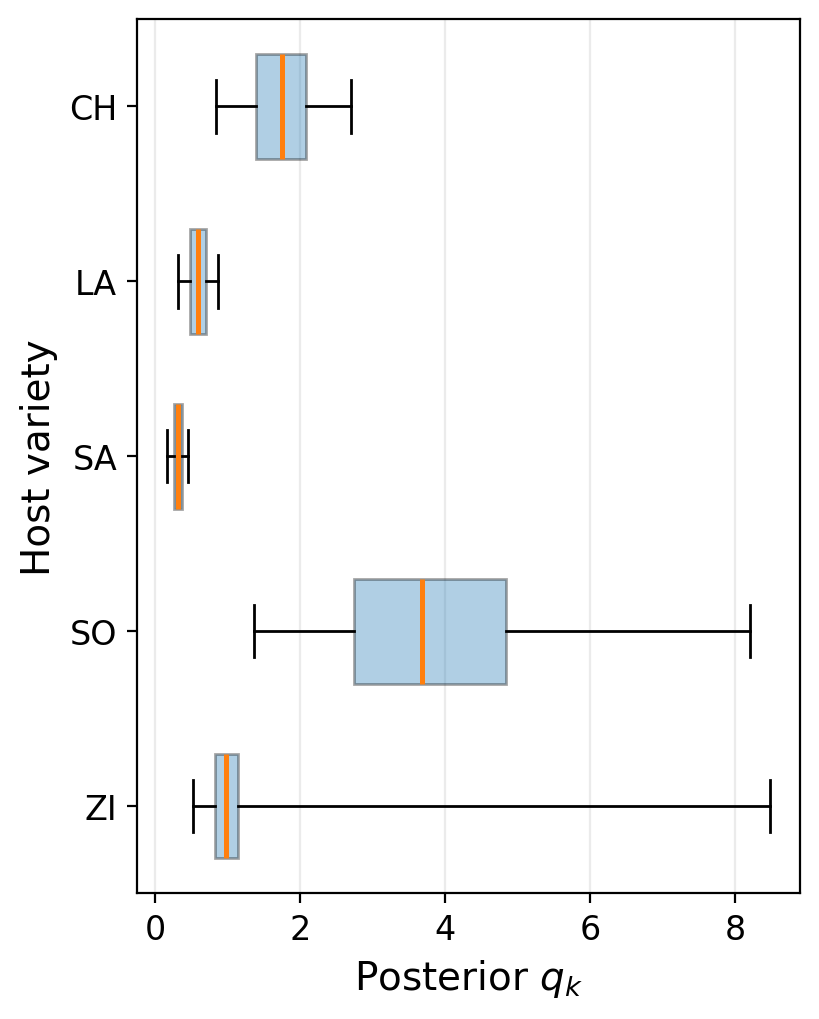

In [29]:
# --- Posterior samples of q_k ---
qks = np.array([theta_to_params(th, N_DIM)[2] for th in samples])
qks = qks[np.all(np.isfinite(qks), axis=1), :]

qk_summary = {
    HOSTS[k]: {
        "mean": float(np.mean(qks[:, k])),
        "median": float(np.median(qks[:, k])),
        "q025": float(np.quantile(qks[:, k], 0.025)),
        "q975": float(np.quantile(qks[:, k], 0.975)),
    }
    for k in range(H)
}

print("Posterior summaries for q_k")
for host, s in qk_summary.items():
    print(f"{host}: mean={s['mean']:.4f}  median={s['median']:.4f}  95% CrI=[{s['q025']:.4f}, {s['q975']:.4f}]")

fig, ax = plt.subplots(figsize=(4.2, 5.2), dpi=200)

bp = ax.boxplot(
    [qks[:, k] for k in range(qks.shape[1])],
    vert=False,
    labels=HOSTS,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
    whis=(2.5, 97.5),
    medianprops=dict(linewidth=1.8),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
)

for box in bp["boxes"]:
    box.set_alpha(0.35)

ax.set_xlabel(r"Posterior $q_k$", fontsize=14)
ax.set_ylabel("Host variety", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig("posterior_qk_n3.png", dpi=300, bbox_inches="tight")
plt.show()


Posterior summaries for q_k
CH: mean=1.7404  median=1.7485  95% CrI=[0.8385, 2.6963]
LA: mean=0.5886  median=0.5895  95% CrI=[0.3114, 0.8617]
SA: mean=0.3072  median=0.3083  95% CrI=[0.1592, 0.4507]
SO: mean=3.9690  median=3.6736  95% CrI=[1.3575, 8.2049]
ZI: mean=1.3520  median=0.9742  95% CrI=[0.5167, 8.4789]


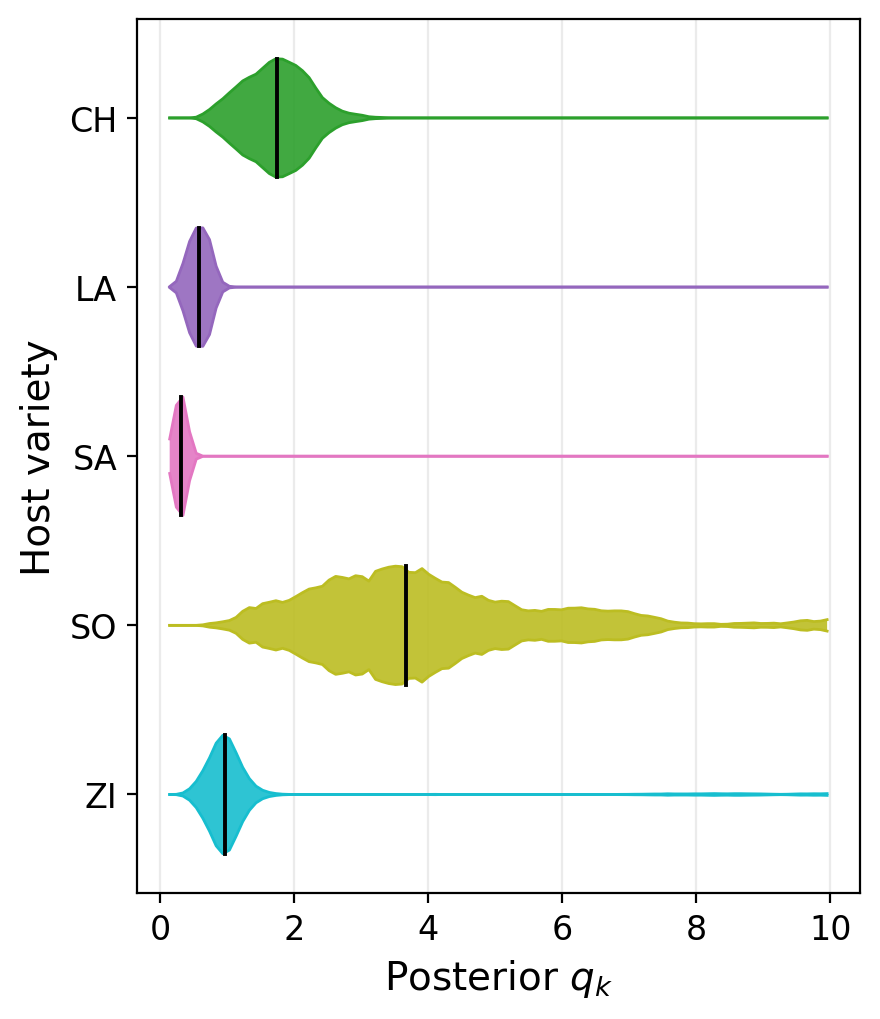

In [30]:
from scipy.ndimage import gaussian_filter1d

# --- Posterior samples of q_k ---
qks = np.array([theta_to_params(th, N_DIM)[2] for th in samples])
qks = qks[np.all(np.isfinite(qks), axis=1), :]   # shape: (n_samples, n_hosts)

qk_summary = {
    HOSTS[k]: {
        "mean": float(np.mean(qks[:, k])),
        "median": float(np.median(qks[:, k])),
        "q025": float(np.quantile(qks[:, k], 0.025)),
        "q975": float(np.quantile(qks[:, k], 0.975)),
    }
    for k in range(H)
}

print("Posterior summaries for q_k")
for host, s in qk_summary.items():
    print(f"{host}: mean={s['mean']:.4f}  median={s['median']:.4f}  95% CrI=[{s['q025']:.4f}, {s['q975']:.4f}]")

# --- Same color palette as in the MDS figure ---
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))
host_to_color = {lab: colors[labels.index(lab)] for lab in HOSTS}

# --- Figure ---
fig, ax = plt.subplots(figsize=(4.5, 5.2), dpi=200)
ypos = np.arange(1, len(HOSTS) + 1)

lower = np.min(qks)
upper = np.max(qks)

n_bins = 100
bins = np.linspace(lower, upper, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

scale = 0.35
sigma = 0.5   # very light smoothing

for y0, host, samp in zip(ypos, HOSTS, qks.T):
    col = host_to_color[host]

    # histogram in density form
    counts, _ = np.histogram(samp, bins=bins, density=True)

    # Gaussian smoothing of histogram counts
    counts_smooth = gaussian_filter1d(counts, sigma=sigma, mode="nearest")

    # normalize for visualization
    h = counts_smooth / counts_smooth.max() * scale

    ax.fill_between(
        bin_centers,
        y0 - h,
        y0 + h,
        facecolor=col,
        edgecolor="none",
        alpha=0.9,
        zorder=2,
    )

    ax.plot(bin_centers, y0 + h, color=col, linewidth=1.0, zorder=3)
    ax.plot(bin_centers, y0 - h, color=col, linewidth=1.0, zorder=3)

    # posterior median
    med = np.median(samp)
    ax.plot([med, med], [y0 - scale, y0 + scale], color="k", linewidth=1.4, zorder=4)

ax.set_yticks(ypos)
ax.set_yticklabels(HOSTS)
ax.invert_yaxis()
ax.set_xlabel(r"Posterior $q_k$", fontsize=14)
ax.set_ylabel("Host variety", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25, zorder=0)

fig.tight_layout()
fig.savefig("posterior_qk_n3.png", dpi=300, bbox_inches="tight")
plt.show()

## 8) Planarity diagnostics for n=3 via MDS eigenvalues

=== PCoA/MDS eigenvalue diagnostics (n=3 fit) ===
Frac(2) = (λ1+λ2)/Σ λ+: mean=0.8793, median=0.8788, 95% CI=[0.7805, 0.9756]
Frac(3) = (λ1+λ2+λ3)/Σ λ+: mean=1.0000, median=1.0000, 95% CI=[1.0000, 1.0000]
Third-axis share = λ3/(λ1+λ2+λ3) using λ+: mean=0.1207, median=0.1212, 95% CI=[0.0244, 0.2195]
λ3+ = max(λ3,0): mean=3.1642, median=2.9809, 95% CI=[0.4496, 7.1448]
Pr(λ3 > 0) across posterior draws: 1.000


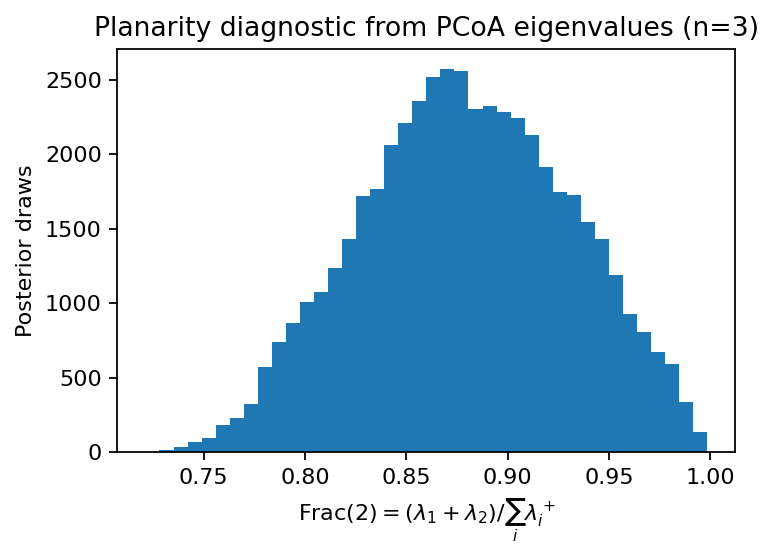

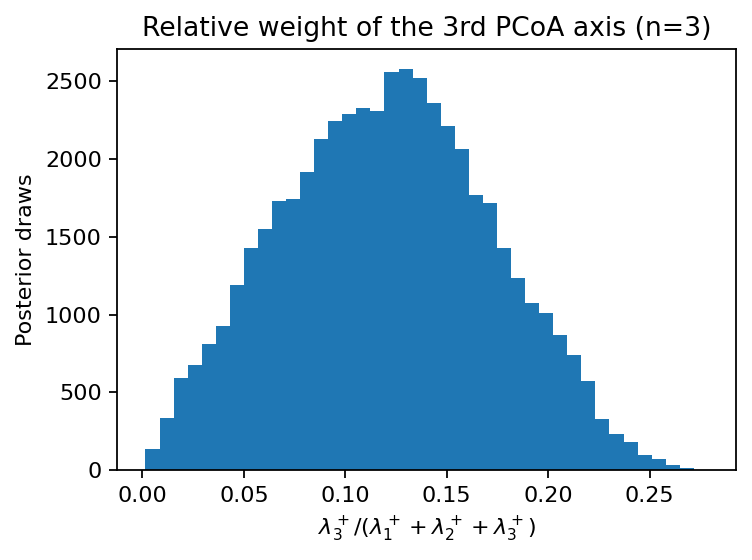

In [17]:
# Computes (i) eigenvalues of B = -1/2 J D^2 J for each posterior draw,
# (ii) fraction of positive-eigenvalue mass captured by first 2 axes (Frac2),
# (iii) relative contribution of the 3rd axis (Frac3_contrib),
# and prints posterior summaries + saves a simple histogram plot.

import numpy as np
import matplotlib.pyplot as plt

def pcoa_eigenvalues(D):
    """
    Return eigenvalues (descending) of the double-centred matrix
    B = -1/2 J D^2 J for a distance matrix D.
    """
    D = np.asarray(D, float)
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    w = np.linalg.eigvalsh(B)          # ascending
    w = w[::-1]                        # descending
    return w

def summarize(x, name):
    x = np.asarray(x, float)
    q = np.quantile(x, [0.025, 0.5, 0.975])
    mean = float(np.mean(x))
    print(f"{name}: mean={mean:.4f}, median={q[1]:.4f}, 95% CI=[{q[0]:.4f}, {q[2]:.4f}]")

# --- Compute eigenvalues for each posterior draw of the distance matrix ---
# Ds must already be defined as array (n_samp, K, K) with K=H+1 (includes CL).
Ws = np.array([pcoa_eigenvalues(D) for D in Ds])   # shape: (n_samp, K)

# Positive-part eigenvalues (consistent with classical MDS practice)
Wp = np.maximum(Ws, 0.0)

# Total positive-eigenvalue mass per draw
mass = Wp.sum(axis=1)

# Avoid division by 0 in pathological draws
eps = 1e-15
mass_safe = np.maximum(mass, eps)

# Fraction of positive mass captured by first 2 axes
Frac2 = (Wp[:, 0] + Wp[:, 1]) / mass_safe

# Fraction captured by first 3 axes
Frac3 = (Wp[:, 0] + Wp[:, 1] + Wp[:, 2]) / mass_safe

# Contribution of the 3rd axis relative to first 3 (often a nice "how 3D is it?" number)
mass3 = np.maximum(Wp[:, 0] + Wp[:, 1] + Wp[:, 2], eps)
Frac3_contrib = Wp[:, 2] / mass3

# Also report the absolute positive 3rd eigenvalue
Lambda3_pos = Wp[:, 2]

# --- Print summaries for the appendix text ---
print("=== PCoA/MDS eigenvalue diagnostics (n=3 fit) ===")
summarize(Frac2, "Frac(2) = (λ1+λ2)/Σ λ+")
summarize(Frac3, "Frac(3) = (λ1+λ2+λ3)/Σ λ+")
summarize(Frac3_contrib, "Third-axis share = λ3/(λ1+λ2+λ3) using λ+")
summarize(Lambda3_pos, "λ3+ = max(λ3,0)")

# Optional: how often is λ3 actually positive?
p_pos3 = float(np.mean(Ws[:, 2] > 0))
print(f"Pr(λ3 > 0) across posterior draws: {p_pos3:.3f}")

# --- Save a simple histogram plot for the appendix (no custom colors) ---
fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=160)
ax.hist(Frac2, bins=40, density=False)
ax.set_xlabel(r"$\mathrm{Frac}(2)=(\lambda_1+\lambda_2)/\sum_i \lambda_i^+$")
ax.set_ylabel("Posterior draws")
ax.set_title("Planarity diagnostic from PCoA eigenvalues (n=3)")
fig.tight_layout()
fig.savefig("appendix_planarity_frac2_n3.png", dpi=300, bbox_inches="tight")
plt.show()

# Optional second histogram: third-axis share among first 3
fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=160)
ax.hist(Frac3_contrib, bins=40, density=False)
ax.set_xlabel(r"$\lambda_3^+/(\lambda_1^+ + \lambda_2^+ + \lambda_3^+)$")
ax.set_ylabel("Posterior draws")
ax.set_title("Relative weight of the 3rd PCoA axis (n=3)")
fig.tight_layout()
fig.savefig("appendix_third_axis_share_n3.png", dpi=300, bbox_inches="tight")
plt.show()
